## Sarima Model
- Exploratory tests
- Fitting the model

Setup

In [672]:
import import_ipynb
import HarmonicAutoRegression as HAR
import pandas as pd
from statsmodels.stats.diagnostic import acorr_breusch_godfrey
from statsmodels.tsa.ardl.pss_critical_values import crit_vals
from statsmodels.tsa.statespace import sarimax
from statsmodels.tsa.stattools import adfuller, kpss
import numpy as np
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import pmdarima
from pmdarima.arima import nsdiffs
from pmdarima.utils import plot_acf, plot_pacf
from statsmodels.graphics.tsaplots import acf, pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg

- Importing data from HAR and designing data frames

In [673]:
temp_data = HAR.TempUnclean

SARIMA_data_temp = pd.concat([HAR.dates, temp_data.apply(HAR.dropstar_tmin, axis=1), temp_data.apply(HAR.dropstar_tmax, axis=1)],axis=1,).astype(float)

SARIMA_data = SARIMA_data_temp.rename(columns={0:'tmin',1:'tmax'})
removed_years_data = HAR.hr_data['tmax']

Determining stationarity on non-seasonal component of SARIMA (d)
- Augmented Dicky-Fuller; tests stationarity H0 is that a unit root exists; there is no mean reversion similar to a random walk.
- KPSS; Null hypothesis is that the time series is stationary

In [674]:
def test_stationarity(series, regression,autolag):
    adf_result = adfuller(series,regression=regression,autolag=autolag,result_object=False)
    kpss_result = kpss(series,regression=regression,result_object=False)
    print("ADF Results:")
    print(f"Test stat: {adf_result[0]}, P Value: {adf_result[1]}, Crit Vals {adf_result[4]}")
    print("KPSS Results:")
    print(f"Test stat: {kpss_result[0]}, P Value: {kpss_result[1]},Crit Vals {kpss_result[3]}")

test_stationarity(removed_years_data,regression='ct',autolag='AIC')

ADF Results:
Test stat: -5.753925601684285, P Value: 7.111768870432921e-06, Crit Vals {'1%': np.float64(-3.9641720721237212), '5%': np.float64(-3.4131081047471175), '10%': np.float64(-3.128591361310234)}
KPSS Results:
Test stat: 0.044259365970257265, P Value: 0.1,Crit Vals {'10%': 0.119, '5%': 0.146, '2.5%': 0.176, '1%': 0.216}


/var/folders/b8/08pp8h193550lzt97xk6gc580000gn/T/ipykernel_1785/655955510.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  kpss_result = kpss(series,regression=regression,result_object=False)


- ADF Result: -5.754 < -3.964 hence we reject H0 concluding that ADF test gives sufficient
evidence to conclude stationarity.
- KPSS Result: 0.044 > 0.216 implying we accept 1% and for KPSS test accepting H0 gives us sufficient evidence to conclude stationarity around a linear trend.

Testing for D; Seasonal differencing term.

In [675]:
def lin_reg_matrix(series):
    t = np.arange(1,len(series)+1)
    n = len(t)
    cols = [np.ones(n), t.astype(float)]
    return np.column_stack(cols)

def remove_lin_trend(series):
    X = lin_reg_matrix(series)
    b,residual,rank,sv = np.linalg.lstsq(X,series,rcond=None)
    y_hat = X @ b
    x = pd.Series(series - y_hat)
    return x,X

detrended_data_test1 = remove_lin_trend(SARIMA_data['tmax'].dropna())
detrended_data_test2 = remove_lin_trend(removed_years_data)[0]

- removed the linear trend from the data using a least squares regression to normalise data
prior to testing as OCSB and CH test are not designed to cope with a linear trend while testing
for a seasonal unit root



In [676]:
OCSB_result = nsdiffs(detrended_data_test2,test='ocsb',m=12,max_D=2)
print(OCSB_result)
CH_result = nsdiffs(detrended_data_test2,test='ch',m=12,max_D=2)
print(CH_result)

0
0


- Initially I did the prior test on the first set of detrended data; outputting 0 for OCSB and 1 for the CH test. Then I proceeded to do the next test to conclude which one it was and determined 1 was the best fit.
- However, given that test 2 is done with years removed I believe it better implies that i should not seasonally difference and that D = 0.

In [677]:

var = removed_years_data.var()
var_diff12 = removed_years_data.diff(12).var()
print(var)
print(var_diff12)

29.43253656210112
4.956715398445113


- Decrease in variance is a crude test I used to determine between 0,1 in the first test.
- It Fails because the drop cant distinguish between the presence of an actual unit root and the fact that there is strong ACF.

Testing for values (p,q) and (P,Q).
- acf and pacf plots;
- by playing around with the plot acf you can see ...

<BarContainer object of 30 artists>

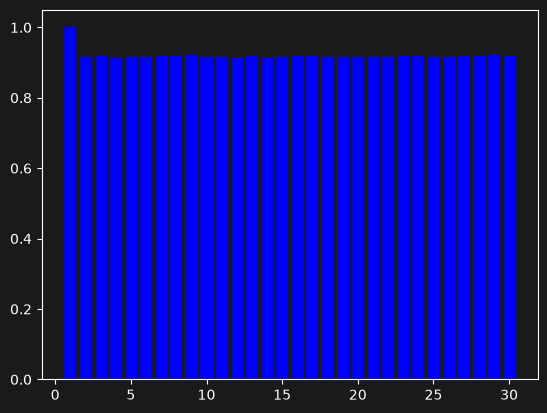

In [704]:
def acf_at_lag(series,lag):
    if lag == 0:
        return 1
    else:
        mean = np.mean(series)
        x = series[lag:] - mean
        y = series[:-lag] - mean
        x = x.reset_index(drop=True)
        y = y.reset_index(drop=True)
        mult = pd.Series.multiply(x,y)
        return np.sum(mult)/np.sum(x ** 2)

def acf_plot(series,seasonal,total_lags,period):
    z = np.zeros(total_lags)
    if not seasonal:
        for i in range(total_lags):
            z[i] = acf_at_lag(series,i)
        return plt.bar(range(1,total_lags+1),z,color='b')
    elif seasonal:
        for i in range(total_lags):
            z[i] = acf_at_lag(series,i * period)
        return plt.bar(range(1,total_lags+1),z,color='b')
    else:
        print("seasonal value must be spesicfied as true or false")

acf_plot(removed_years_data,seasonal=True,total_lags=30,period=12)



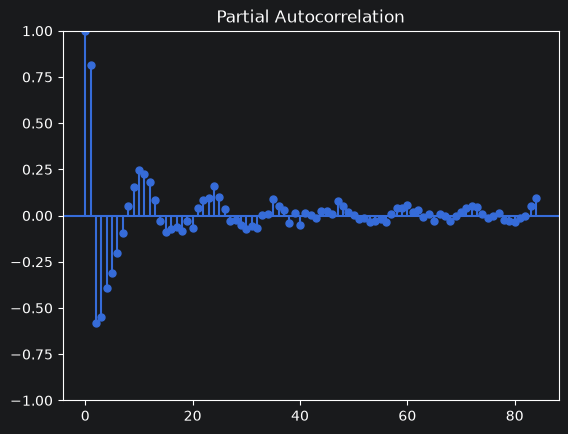

In [701]:
plot_pacf(removed_years_data,lags=84)

- acf doesn't decay at all giving us no meaningful information on the series's behavior
- pacf decays fast over seasonal spikes which points to a seasonal ARMA process

In [ ]:
def Bartletts_test(series,lags,seasonal,step):
    n = len(series)
    acf_vals = acf(series,nlags=lags,fft=True)
    if seasonal:
        seasonal_lags = list(range(step,lags,step))
        r_seasonal = [acf_vals[l] for l in seasonal_lags]

        for i, lag in enumerate(seasonal_lags):
            prior = r_seasonal[:i]
            se = np.sqrt((1/n) * (1 + 2*sum(r**2 for r in prior)))
            z = r_seasonal[i] / se
            print(f"lag {lag}:, acf value at lag {r_seasonal[i]}, sig={abs(z)>1.96}")
    elif not seasonal:
        lags = list(range(1,lags+1))
        r_lags = [acf_vals[l] for l in lags]
        for i, lag in enumerate(lags):
            prior = r_lags[:i]
            se = np.sqrt((1/n) * (1 + 2*sum(r**2 for r in prior)))
            z = r_lags[i] / se
            print(f"lag {lag}:, acf value at lag {r_lags[i]}, sig={abs(z)>1.96}")
    else:
        print('true false error on seasonal')

Bartletts_test(removed_years_data,240,seasonal=True,step=12) # Test 1


- Bartlett's test gives a meaningful measurement that looks at the sample ACF values and weather the random noise they have is from an actual MA(q) or just random noise.
- The first test on the years removed data has a very high acf values which makes me believe that there is not a purely MA(q) but an ARMA(p,q) process hidden in the seasonal
ACF values.
- Bartlett's test requires a sharp cut-off of acf values which is not present here hence the
test is inconclusive.

EACF (Extended Autocorrelation Function)

In [ ]:
def lagmat(series,lags):
    n = len(series)
    cols = []
    for i in range(1,lags+1):
        c = np.zeros(n)
        c[i:] = series[:-i]
        cols.append(c)
    return np.column_stack(cols) if cols else print("error on lagmat")



data = pd.Series(remove_lin_trend(removed_years_data)[0])
print(lagmat(data,4))



- lagmat constructs a matrix of observed values shifted down by the lag for each column
(lag)
- acf_at_lag computes acf at that lag.
- Removed linear trend so it doesnt cause any issues with following tests.

In [716]:


def eacf(z,ar_max,ma_max,period): #takes inputs series,maximum ar order and max ma order.
    ## first step check acf initially prior to liner regression
    acf_mat = np.zeros((ar_max,ma_max))
    for i in range(ma_max):
        acf_mat[0,i] = acf_at_lag(z,period * i)

    ##fit linear regression
    for i in range(1,ar_max):
        lag_mat = lagmat(z,ma_max)

        b,residual,rank,sv = np.linalg.lstsq(lag_mat,z,rcond=None)
        y_hat = lag_mat @ b

        ## define residuals
        z = z - y_hat

        ##alter acf matrix
        for k in range(ma_max):
            acf_mat[i,k] = acf_at_lag(z,period * k)

        # Comparion
        checking_matrix = np.zeros((ar_max,ma_max))
        for i in range(ar_max):
            for j in range(ma_max):
                checking_matrix[i,j] = 2/np.sqrt(len(removed_years_data)-i-j)

        result = acf_mat < checking_matrix
    return result

print(seasonal_eacf(data,4,6,12))





[[False False False False False False]
 [False False False False False False]
 [False  True False False False False]
 [False  True False False False False]]


- the fact that there is no point where all values after it are significant is an issue
as a true MA(p) process has a sharp cut off followed by the following values also being significant
- So im going to difference the series seasonally and then re-apply Eacf test


In [720]:
differenced_data = data.diff(12).dropna()

print(seasonal_eacf(differenced_data,4,6,12))


[[False  True  True  True  True  True]
 [False  True  True  True  True  True]
 [False  True  True  True  True  True]
 [False  True  True  True  True  True]]


- the prior indicates AR(0) MA(1) to verify this on the differenced series we will
do Bartlett's test and Quenouille's test

In [731]:
def Quenouilles_test(series,lags,seasonal):
    n = len(series)
    pacf_vals = pacf(series,nlags=lags,method= 'ywm')
    if seasonal:
        seasonal_lags = [12,24,36,48,60,72]

        SE = 1/np.sqrt(n)
        for lag in seasonal_lags:
            z = pacf_vals[lag]/SE
            print(f"lag {lag}: phi={pacf_vals[lag]:.4f}  z={z:.2f}  sig={abs(z)>1.96}")
    elif not seasonal:
        lags = list(range(1,lags+1))

        SE = 1/np.sqrt(n)
        for lag in lags:
            z = pacf_vals[lag]/SE
            print(f"lag {lag}: phi={pacf_vals[lag]:.4f}  z={z:.2f} sig={abs(z)>1.96}")
    else:
        print('true false error on seasonal')

# Quenouilles_test(differenced_data,72,seasonal=True)
# Bartletts_test(differenced_data,72,seasonal=True,step=12)

tentative = SARIMAX(data,order=(0,0,0),seasonal_order = (0,1,1,12)).fit()
data_S_Quen = data - tentative.fittedvalues

Quenouilles_test(data_S_Quen,72,seasonal=True)

lag 12: phi=-0.0171  z=-0.70  sig=False
lag 24: phi=0.0327  z=1.35  sig=False
lag 36: phi=-0.0259  z=-1.07  sig=False
lag 48: phi=-0.0176  z=-0.73  sig=False
lag 60: phi=-0.0027  z=-0.11  sig=False
lag 72: phi=-0.0039  z=-0.16  sig=False


- Bartlett's test indicates MA(1) but Quenouille's test indicates AR of order at least 6
this is because an MA(1) can be expressed as an infinite sequence of AR variables.
- t
- The results of these tests conclude that MA(1) is the correct order and AR process is
in fact AR(0) - no AR component.

Testing for non seasonal AR/MA components.

In [740]:
## We already know that series is stationary so we go and test AR/MA processes.

testing_data = data_S_Quen


## EACF result
# eacf(testing_data,4,6,1)

## Bartlett's test and Quenouilles test results
# Bartletts_test(testing_data,6,seasonal=False,step=1)
#
# temp = SARIMAX(testing_data,order=(0,0,2)).fit()
# testing_data_q = testing_data - temp.fittedvalues
# Quenouilles_test(testing_data_q,6,seasonal=False)

lag 1: phi=0.0013  z=0.06 sig=False
lag 2: phi=0.0050  z=0.21 sig=False
lag 3: phi=0.0309  z=1.28 sig=False
lag 4: phi=0.0149  z=0.62 sig=False
lag 5: phi=0.0066  z=0.27 sig=False
lag 6: phi=0.0235  z=0.97 sig=False


- Eacf test suggests AR(0) MA(3)
- Bartlett's and Quenouilles suggests MA(2) AR(0) however z values after seem to trend upwards so we should further check models log likelihood and AIC and BIC values to determine which model is better.

In [742]:
SARIMA_model = SARIMAX(SARIMA_data['tmax'],
                       order=(0,0,2),
                       seasonal_order=(0,1,1,12)).fit()
print(SARIMA_model.summary())


                                      SARIMAX Results                                       
Dep. Variable:                                 tmax   No. Observations:                 1743
Model:             SARIMAX(0, 0, 2)x(0, 1, [1], 12)   Log Likelihood               -3211.697
Date:                              Mon, 05 Oct 2026   AIC                           6431.393
Time:                                      10:26:54   BIC                           6453.219
Sample:                                           0   HQIC                          6439.466
                                             - 1743                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2583      0.023     11.324      0.000       0.214       0.303
ma.L2          0.13

- SARIMA(0,0,3)(0,1,1,12) has AIC: 6429.504, BIC: 6456.786, LL: -3209.752
- SARIMA(0,0,2)(0,1,1,12) has AIC: 6431.393, BIC: 6453.219, LL: -3211.697

- using BIC as it works better for explaining trends SARIMA(0,0,2)(0,1,1,12) is the prefered model.

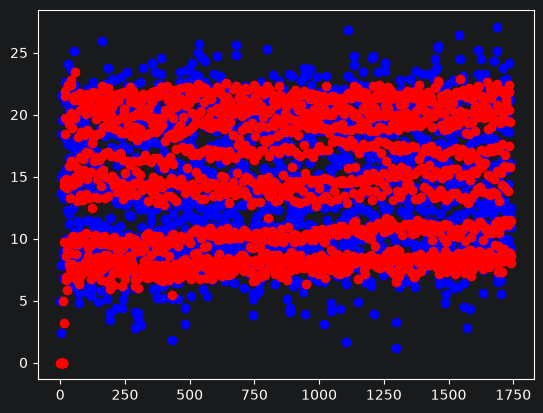

In [750]:
plt.scatter(range(len(SARIMA_data)),SARIMA_data['tmax'],color='b')
plt.scatter(range(len(SARIMA_model.fittedvalues)),SARIMA_model.fittedvalues,color='r')